# House Price Prediction — Data Cleaning, Modeling & Export

**Dataset:** [House Price by Juhi Bhojani](https://www.kaggle.com/datasets/juhibhojani/house-price) (Kaggle)

This notebook:
1. Loads and inspects the raw data
2. Explores it visually (EDA)
3. Cleans messy text fields and engineers features
4. Trains and compares multiple regression models
5. Evaluates the best model on a held-out test set
6. Exports the trained pipeline (`house_price.pkl`) for the FastAPI backend

> **Note:** Place `house_prices.csv` in `data/` before running (see Phase 1 of the project guide,
> or use the Kaggle CLI: `kaggle datasets download -d juhibhojani/house-price -p data --unzip`).


## 2.1 Load & Inspect

In [ ]:
import re
import json
import joblib
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(f"scikit-learn version: {sklearn.__version__}")

scikit-learn version: 1.6.1


In [ ]:
# Load dataset
data_path = "/content/house_prices.csv"
df_raw = pd.read_csv(data_path)

print(f"Dataset Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns\n")
print("--- First 5 Rows ---")
display(df_raw.head())

print("\n--- Column Info & Data Types ---")
df_raw.info()

Dataset Shape: 187,531 rows, 21 columns

--- First 5 Rows ---


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN



--- Column Info & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony          

In [ ]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,187531.0,NaN,NaN,NaN,93765.0,54135.681003,0.0,46882.5,93765.0,140647.5,187530.0
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,184508,65634,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),187531,1561,Call for Price,9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),169866.0,NaN,NaN,NaN,7583.771885,27241.705819,0.0,4297.0,6034.0,9450.0,6700000.0
location,187531,81,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,106858,2758,1000 sqft,5285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,186916,1,Ready to Move,186916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,180454,947,2 out of 4,12433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,187448,4,Resale,144172,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_summary = pd.DataFrame({
    'Missing Values': df_raw.isna().sum(),
    'Percentage (%)': (df_raw.isna().mean() * 100).round(2),
    'Data Type': df_raw.dtypes
}).sort_values(by='Percentage (%)', ascending=False)

display(missing_summary)

,Missing Values,Percentage (%),Data Type
Plot Area,187531,100.00,float64
Dimensions,187531,100.00,float64
Society,109678,58.49,object
Super Area,107685,57.42,object
Car Parking,103357,55.11,object
overlooking,81436,43.43,object
Carpet Area,80673,43.02,object
facing,70233,37.45,object
Ownership,65517,34.94,object
Balcony,48935,26.09,object


In [ ]:
def parse_price(val):
    """Parses price strings like '42 Lac', '1.2 Cr', '50,000' to numeric rupees."""
    if not isinstance(val, str):
        return np.nan
    val = val.strip().lower()
    try:
        if 'cr' in val:
            num = float(re.findall(r"[-+]?(?:\d*\.\d+|\d+)", val)[0])
            return num * 1e7
        elif 'lac' in val or 'lakh' in val:
            num = float(re.findall(r"[-+]?(?:\d*\.\d+|\d+)", val)[0])
            return num * 1e5
        else:
            clean_str = val.replace(',', '').replace('₹', '').strip()
            return float(clean_str)
    except (IndexError, ValueError):
        return np.nan


def parse_area(val):
    """Extracts numeric area and normalizes sqm/sqyrd to sqft."""
    if not isinstance(val, str):
        return np.nan
    val = val.strip().lower()
    try:
        nums = re.findall(r"[-+]?(?:\d*\.\d+|\d+)", val.replace(',', ''))
        if not nums:
            return np.nan
        area = float(nums[0])
        if 'sqm' in val:
            area *= 10.7639
        elif 'sqyrd' in val or 'sq.yrd' in val:
            area *= 9.0
        return area
    except (IndexError, ValueError):
        return np.nan


def parse_floor(val):
    """Extracts floor number handling special cases like Ground, Basement, etc."""
    if not isinstance(val, str):
        return np.nan
    val = val.strip().lower()
    if 'basement' in val:
        return -1.0
    if 'ground' in val:
        return 0.0
    try:
        # Matches patterns like '3 out of 10' -> extracts '3'
        nums = re.findall(r"\d+", val)
        return float(nums[0]) if nums else np.nan
    except (IndexError, ValueError):
        return np.nan


def parse_numeric(val):
    """Extracts first integer for counts (Bathrooms, Balconies, etc.)."""
    if not isinstance(val, str):
        return val if isinstance(val, (int, float)) else np.nan
    nums = re.findall(r"\d+", val)
    return float(nums[0]) if nums else np.nan

In [ ]:
df = df_raw.copy()

# 1. Clean Target
df['price_clean'] = df['Amount(in rupees)'].apply(parse_price)
df = df.dropna(subset=['price_clean'])
df = df[df['price_clean'] > 10000] # Drop invalid/token zero amounts

# 2. Clean Numeric Features
# Fallback to Super Area if Carpet Area is missing
df['carpet_area_sqft'] = df['Carpet Area'].apply(parse_area)
df['super_area_sqft'] = df['Super Area'].apply(parse_area)
df['carpet_area_sqft'] = df['carpet_area_sqft'].fillna(df['super_area_sqft'])

df['floor_num'] = df['Floor'].apply(parse_floor)
df['bathroom'] = df['Bathroom'].apply(parse_numeric)
df['balcony'] = df['Balcony'].apply(parse_numeric)

# Drop rows without basic usable area
df = df.dropna(subset=['carpet_area_sqft'])
df = df[df['carpet_area_sqft'] > 50] # Filter impossible micro dimensions

# 3. Handle High-Cardinality Categoricals (Top 50 locations -> others to 'other')
top_locations = df['location'].value_counts().nlargest(50).index.tolist()
df['location_grouped'] = df['location'].apply(lambda x: x if x in top_locations else 'other')

# Standardize remaining categoricals
categorical_cols = ['Furnishing', 'Transaction', 'Ownership', 'facing']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().replace({'nan': 'Unknown'})
    else:
        df[col] = 'Unknown'

# 4. Outlier Removal via Price-per-sqft (1st to 99th Percentile)
df['price_per_sqft'] = df['price_clean'] / df['carpet_area_sqft']
lower_bound = df['price_per_sqft'].quantile(0.01)
upper_bound = df['price_per_sqft'].quantile(0.99)

df = df[(df['price_per_sqft'] >= lower_bound) & (df['price_per_sqft'] <= upper_bound)]

print(f"Cleaned dataset rows ready for training: {len(df):,}")

Cleaned dataset rows ready for training: 173,605


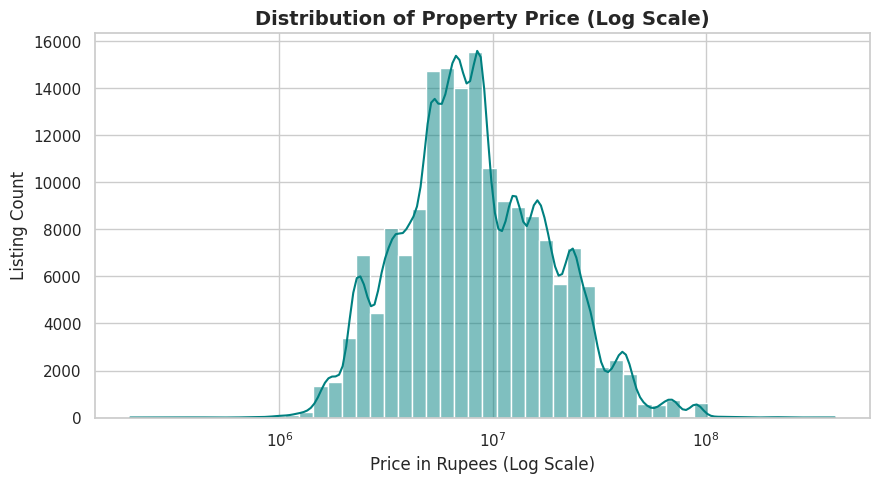

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price_clean"], bins=50, kde=True, log_scale=True, color='teal')
plt.title("Distribution of Property Price (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Price in Rupees (Log Scale)")
plt.ylabel("Listing Count")
plt.show()

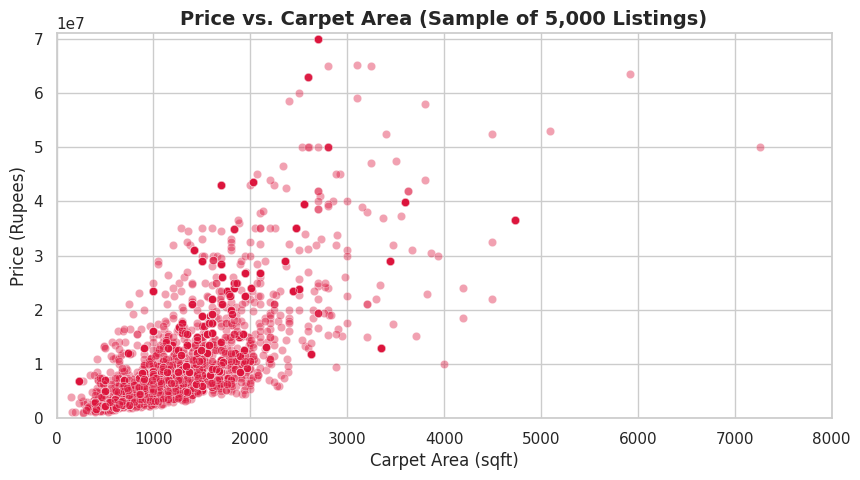

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.4,
    color='crimson'
)
plt.title("Price vs. Carpet Area (Sample of 5,000 Listings)", fontsize=14, fontweight='bold')
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Rupees)")
plt.xlim(0, 8000)
plt.ylim(0, df['price_clean'].quantile(0.995))
plt.show()

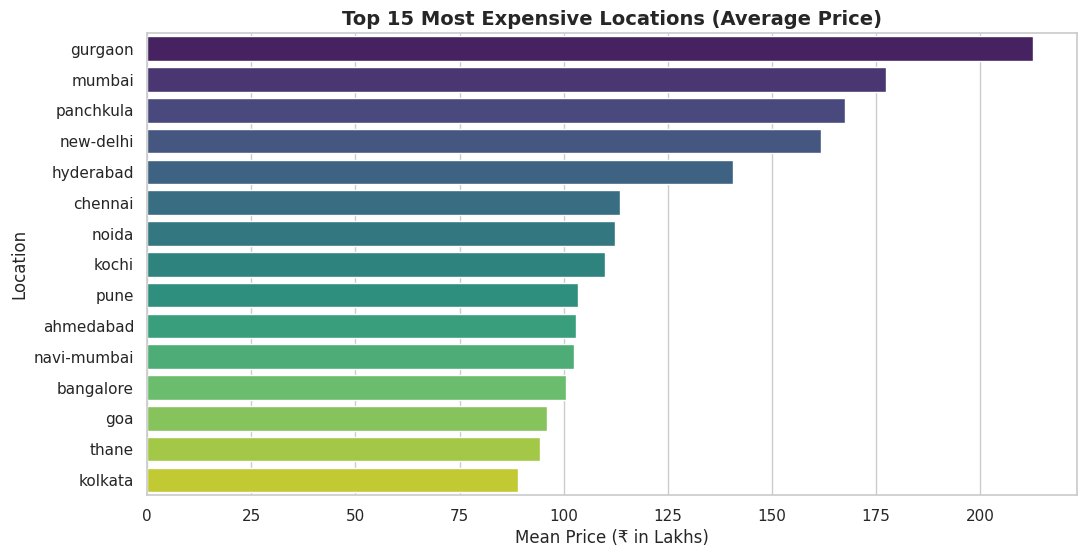

In [ ]:
top_15_locs = df[df['location_grouped'] != 'other'].groupby('location_grouped')['price_clean'].mean().nlargest(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_15_locs.values / 1e5,
    y=top_15_locs.index,
    hue=top_15_locs.index,
    palette='viridis',
    legend=False
)
plt.title("Top 15 Most Expensive Locations (Average Price)", fontsize=14, fontweight='bold')
plt.xlabel("Mean Price (₹ in Lakhs)")
plt.ylabel("Location")
plt.show()

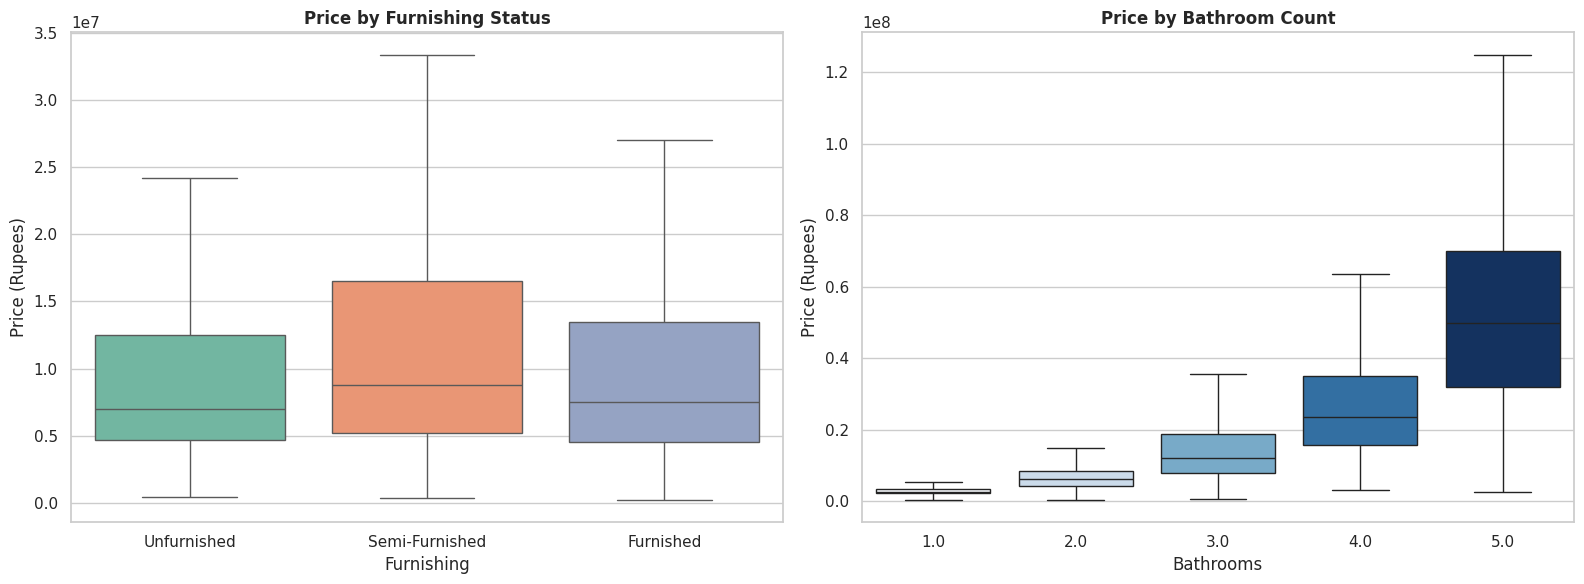

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot 1: Furnishing Status
sns.boxplot(
    ax=axes[0],
    data=df[df['Furnishing'].isin(['Furnished', 'Semi-Furnished', 'Unfurnished'])],
    x='Furnishing',
    y='price_clean',
    hue='Furnishing',
    palette='Set2',
    legend=False,
    showfliers=False
)
axes[0].set_title("Price by Furnishing Status", fontweight='bold')
axes[0].set_ylabel("Price (Rupees)")

# Boxplot 2: Bathrooms (1 to 5)
# Assign 'x' to 'hue' to satisfy modern Seaborn guidelines
sns.boxplot(
    ax=axes[1],
    data=df[df['bathroom'].isin([1, 2, 3, 4, 5])],
    x='bathroom',
    y='price_clean',
    hue='bathroom',
    palette='Blues',
    legend=False,
    showfliers=False
)
axes[1].set_title("Price by Bathroom Count", fontweight='bold')
axes[1].set_ylabel("Price (Rupees)")
axes[1].set_xlabel("Bathrooms")

plt.tight_layout()
plt.show()

In [ ]:
# Feature sets
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

X = df[numeric_features + categorical_features]
y = df["price_clean"]
y_log = np.log1p(y)

# 80/20 Train-Test Split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
y_test = np.expm1(y_test_log)

# Transformer Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_features)
    ]
)

# Models to compare
models = {
    "Linear Regression (Baseline)": LinearRegression(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=150, random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)
}

trained_pipelines = {}
for name, regressor in models.items():
    print(f"Training {name}...")
    pipeline = Pipeline(steps=[
        ("prep", preprocessor),
        ("reg", regressor)
    ])
    pipeline.fit(X_train, y_train_log)
    trained_pipelines[name] = pipeline

Training Linear Regression (Baseline)...
Training Gradient Boosting Regressor...
Training Random Forest Regressor...


In [ ]:
results = []

for name, pipe in trained_pipelines.items():
    preds_log = pipe.predict(X_test)
    preds = np.expm1(preds_log)

    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE (₹)": f"{mae:,.2f}",
        "RMSE (₹)": f"{rmse:,.2f}",
        "R² Score": round(r2, 4),
        "_r2_raw": r2  # Internal sort key
    })

eval_df = pd.DataFrame(results).sort_values(by="_r2_raw", ascending=False).drop(columns=["_r2_raw"])
display(eval_df)

,Model,MAE (₹),RMSE (₹),R² Score
2,Random Forest Regressor,"968,121.52","3,288,674.14",9.237000e-01
1,Gradient Boosting Regressor,"2,508,638.14","4,788,987.76",8.383000e-01
0,Linear Regression (Baseline),"277,999,660.83","49,645,497,870.39",-1.738221e+07


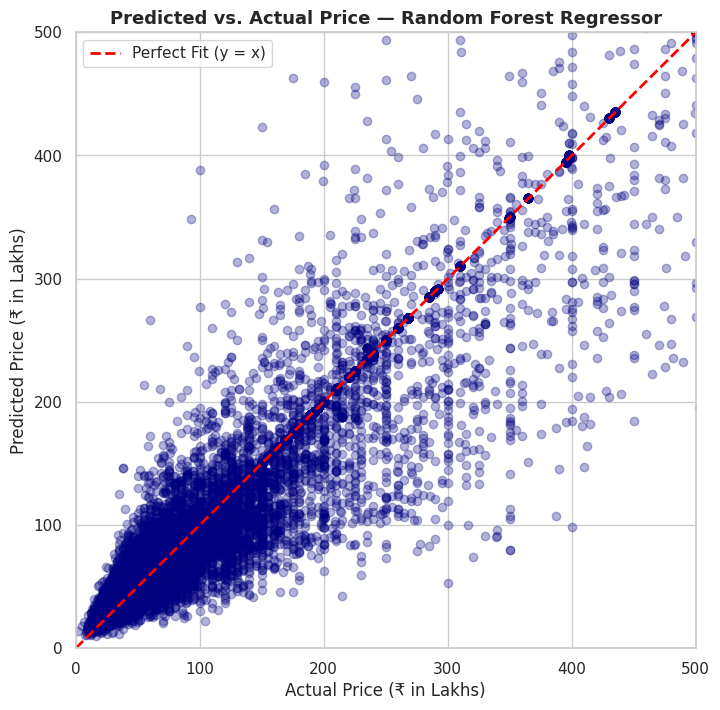

In [ ]:
best_model_name = "Random Forest Regressor"
best_pipeline = trained_pipelines[best_model_name]
winner_preds = np.expm1(best_pipeline.predict(X_test))

plt.figure(figsize=(8, 8))
plt.scatter(y_test / 1e5, winner_preds / 1e5, alpha=0.3, color='navy')
max_val = max(y_test.max(), winner_preds.max()) / 1e5
plt.plot([0, max_val], [0, max_val], '--', color='red', linewidth=2, label="Perfect Fit (y = x)")

plt.title(f"Predicted vs. Actual Price — {best_model_name}", fontsize=13, fontweight='bold')
plt.xlabel("Actual Price (₹ in Lakhs)")
plt.ylabel("Predicted Price (₹ in Lakhs)")
plt.xlim(0, 500)
plt.ylim(0, 500)
plt.legend()
plt.show()

In [ ]:
# 1. Export the full pipeline (includes preprocessing + model)
# Note: For deployment, wrap in an end-to-end wrapper or predict with expm1 on backend
model_filename = "house_price.pkl"
joblib.dump(best_pipeline, model_filename)
print(f" Saved pipeline model to: {model_filename}")

# 2. Sanity Check Reload
loaded_model = joblib.load(model_filename)
sample_record = X_test.iloc[[0]]
sample_pred_log = loaded_model.predict(sample_record)
sample_pred = np.expm1(sample_pred_log)[0]

print(f" Sample Test Record:\n{sample_record.to_dict(orient='records')[0]}")
print(f" Reloaded Model Predicted Price: ₹{sample_pred:,.2f}")

# 3. Export allowed locations for React frontend dropdown
unique_locations = sorted(df['location_grouped'].unique().tolist())
# Place 'other' at the end of the dropdown list
if 'other' in unique_locations:
    unique_locations.remove('other')
    unique_locations.append('other')

locations_filename = "locations.json"
with open(locations_filename, "w") as f:
    json.dump(unique_locations, f, indent=2)

print(f" Saved {len(unique_locations)} valid locations to: {locations_filename}")

 Saved pipeline model to: house_price.pkl
 Sample Test Record:
{'carpet_area_sqft': 405.0, 'floor_num': 0.0, 'bathroom': 1.0, 'balcony': nan, 'location_grouped': 'new-delhi', 'Furnishing': 'Unfurnished', 'Transaction': 'Resale', 'Ownership': 'Freehold', 'facing': 'East'}
 Reloaded Model Predicted Price: ₹3,983,275.55
 Saved 51 valid locations to: locations.json
